# Normalisation

We will work with the minmax scaler in the Scikit-learn package. Before scale the
data we will look at some statistics. 

## Do we need normalization for different classifiers?

*Decision Tree Classifier:*
Normalization is not needed. Decision trees split data based on thresholds of features, not distances. Scaling features won’t change the structure of the tree or the resulting classification.

*KNN Classifier:*
Normalization is needed. KNN relies on distances between data points. If features are on different scales, features with larger ranges dominate the distance calculation, which can bias the classifier. Normalization ensures all features contribute equally.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline


train_df = pd.read_pickle('../pickles/combined/train_df.pkl')
test_df = pd.read_pickle('../pickles/combined/test_df.pkl')

print("Train shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())

X_train = train_df.drop('class', axis=1)
y_train = train_df['class']

X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

Train shape: (23566, 7)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'class']


## Normalize features using MinMaxScaler

In [2]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Evaluate KNN without and with normalization

We use 5-fold cross-validation. For k (number of neighbors), we search odd values from 1 to 25 (1,3,5,...,25). For each candidate k, we run 5-fold cross-validation and calculate the average accuracy. At the end, the cross-validation tells us which k gives the best average accuracy.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

k_values = list(range(1, 26, 2))
param_grid = {'n_neighbors': k_values}

grid = GridSearchCV(knn,
                    param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1,
                    refit=True)

grid.fit(X_train_scaled, y_train_enc)

print("Best params:", grid.best_params_)
print("Best CV accuracy: {:.4f}".format(grid.best_score_))

Best params: {'n_neighbors': 9}
Best CV accuracy: 0.9028


Let's plot CV accuracy as a function of k

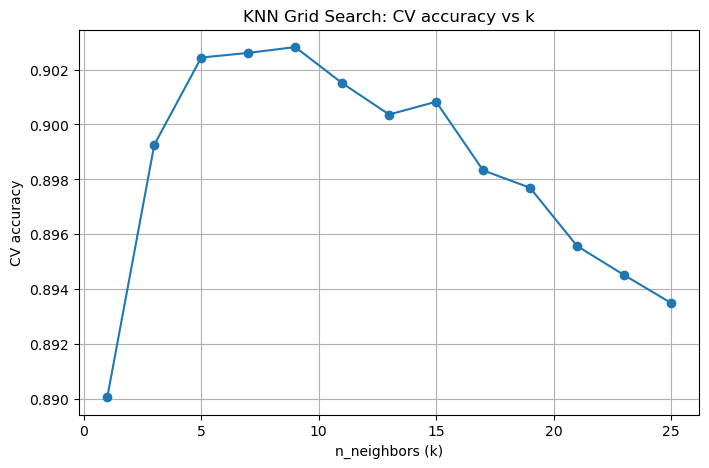

In [4]:
cv_results = pd.DataFrame(grid.cv_results_)

scores = cv_results[['param_n_neighbors', 'mean_test_score']]

# Plot accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(scores['param_n_neighbors'], scores['mean_test_score'], marker='o')
plt.xlabel('n_neighbors (k)')
plt.ylabel('CV accuracy')
plt.title('KNN Grid Search: CV accuracy vs k')
plt.grid(True)
plt.show()

After hyperparameter selection, a final test evaluation gives an unbiased estimate of performance (since test set was not used in tuning).

In [5]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_scaled)
y_test_pred_labels = le.inverse_transform(y_test_pred)
y_test_labels = y_test.values

test_acc = accuracy_score(y_test_enc, y_test_pred)
print("Test accuracy (KNN with best k): {:.4f}".format(test_acc))

print("\nClassification report (test):")
print(classification_report(y_test_labels, y_test_pred_labels, digits=4))


Test accuracy (KNN with best k): 0.9373

Classification report (test):
              precision    recall  f1-score   support

     jumping     0.9169    0.8925    0.9045      1088
     running     0.9532    0.8946    0.9229      1138
      stairs     0.9568    0.9625    0.9597      1841
     walking     0.9103    0.9851    0.9462      1071

    accuracy                         0.9373      5138
   macro avg     0.9343    0.9336    0.9333      5138
weighted avg     0.9379    0.9373    0.9370      5138



Let's plot the confusion matrix

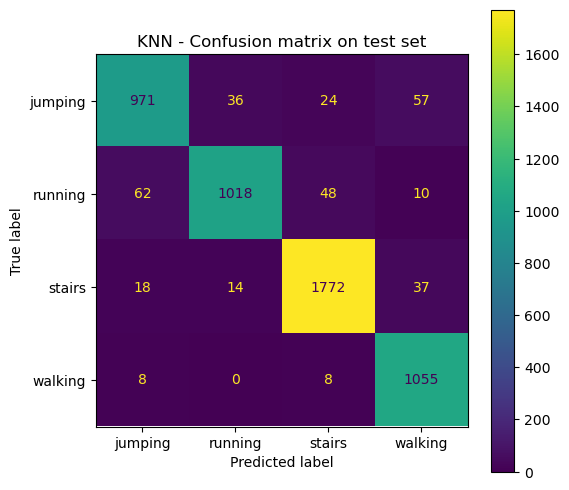

In [6]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test_labels, y_test_pred_labels),
                              display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, values_format='d')
plt.title('KNN - Confusion matrix on test set')
plt.show()


## Which one give the best result, KNN, KNN-normalized or Decision tree?

The best resul was givevn by KNN-normalized with 93.73% test accuracy compared to KNN without normalization with 91.71% test accuracy.